# 4. Final Model Comparison

**Objective:** Compare all approaches on the same test set.

Models compared:
1. **Autoencoder (best variant)** — our main unsupervised model
2. **Supervised DNN** — internal deep learning comparison
3. **Logistic Regression** — simple linear baseline
4. **Random Forest** — classic ML baseline
5. **XGBoost** — tabular SOTA
6. **LightGBM** — tabular SOTA

Satisfies rubric expectation #3: "Give a quick comparison of your model
performance against some state-of-the-art ones. You are not expected to
beat the state-of-the-art models!"

## 4.1 Setup

In [3]:
%matplotlib inline

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.model import FraudDetectorDNN
from src.evaluate import (compute_reconstruction_errors, evaluate,
                          find_threshold_by_percentile, find_optimal_threshold,
                          get_predictions)
from src.baselines import run_all_baselines
from src.utils import get_device, set_seed, load_checkpoint
from src.dataset import FraudDataset

set_seed(42)
device = get_device()
data = load_processed("../data/processed", "../models")
print(f"Test set: {data['x_test'].shape}, fraud rate: {data['y_test'].mean():.2%}")

Test set: (246787, 16), fraud rate: 14.96%


## 4.2 Load Best Autoencoder

Load the best variant from Notebook 2. If you identified a different winner,
update the checkpoint path and hidden_dims below.

In [4]:
# Load the best autoencoder (update path if a different variant won)
ae_checkpoint = load_checkpoint("../models/autoencoder_best.pt", device)
ae_meta = ae_checkpoint["metadata"]
print(f"Autoencoder config: {ae_meta}")

ae_model = build_autoencoder(
    model_type=ae_meta["model_type"],
    input_dim=ae_meta["input_dim"],
    hidden_dims=ae_meta["hidden_dims"],
    dropout=ae_meta["dropout"],
).to(device)
ae_model.load_state_dict(ae_checkpoint["model_state_dict"])
ae_model.eval()

# Evaluate on test set
test_ds = FraudDataset(data["x_test"], data["y_test"])
test_loader = DataLoader(test_ds, batch_size=1024)

ae_errors, ae_labels = compute_reconstruction_errors(ae_model, test_loader, device)
ae_threshold = float(ae_meta["threshold_unsupervised"])
print(f"\nAutoencoder threshold: {ae_threshold:.6f}")
ae_metrics = evaluate(ae_errors, ae_labels, ae_threshold, label="Autoencoder")

Autoencoder config: {'model_type': 'vanilla', 'input_dim': 16, 'hidden_dims': [128, 64, 32], 'dropout': 0.2, 'threshold_unsupervised': 0.020602332428097725, 'best_epoch': 32, 'best_val_loss': 0.011492441248783819, 'test_pr_auc': 0.39107253491020955, 'test_f1': 0.32420591456736036}

Autoencoder threshold: 0.020602

  Autoencoder Set Evaluation   (threshold = 0.020602)
              precision    recall  f1-score   support

      Normal     0.8830    0.8999    0.8914    209868
       Fraud     0.3618    0.3225    0.3410     36919

    accuracy                         0.8135    246787
   macro avg     0.6224    0.6112    0.6162    246787
weighted avg     0.8051    0.8135    0.8091    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        188864        21004
  True Fraud          25014        11905

  ROC-AUC:  0.6766
  PR-AUC:   0.3832  (better metric for imbalanced data)
  F1:       0.3410


## 4.3 Load Supervised DNN

Trained in Notebook 3.

In [5]:
# Load supervised DNN
try:
    dnn_checkpoint = load_checkpoint("../models/supervised_best.pt", device)
    dnn_meta = dnn_checkpoint["metadata"]
    dnn_model = FraudDetectorDNN(
        input_dim=dnn_meta["input_dim"],
        hidden_dims=dnn_meta["hidden_dims"],
        dropout=dnn_meta["dropout"],
    ).to(device)
    dnn_model.load_state_dict(dnn_checkpoint["model_state_dict"])
    dnn_model.eval()
    
    dnn_probs, dnn_labels = get_predictions(dnn_model, test_loader, device)
    dnn_threshold = float(dnn_meta["threshold"])
    dnn_metrics = evaluate(dnn_probs, dnn_labels, dnn_threshold, label="Supervised DNN")
except FileNotFoundError:
    print("supervised_best.pt not found. Run Notebook 3 first.")
    dnn_metrics = None


  Supervised DNN Set Evaluation   (threshold = 0.662378)
              precision    recall  f1-score   support

      Normal     0.9205    0.9032    0.9118    209868
       Fraud     0.5028    0.5566    0.5284     36919

    accuracy                         0.8513    246787
   macro avg     0.7117    0.7299    0.7201    246787
weighted avg     0.8580    0.8513    0.8544    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        189549        20319
  True Fraud          16369        20550

  ROC-AUC:  0.8132
  PR-AUC:   0.5708  (better metric for imbalanced data)
  F1:       0.5284


## 4.4 Run SOTA Baselines

Logistic Regression, Random Forest, XGBoost, and LightGBM.
These are genuinely state-of-the-art for tabular fraud detection.

In [6]:
# Build supervised training data (same logic as Notebook 3)
rng = np.random.default_rng(42)
perm = rng.permutation(len(data["y_val"]))
half = len(perm) // 2

x_train_sup = np.concatenate([data["x_train"], data["x_val"][perm[:half]]])
y_train_sup = np.concatenate([
    np.zeros(len(data["x_train"]), dtype=np.int64),
    data["y_val"][perm[:half]],
])

baseline_results = run_all_baselines(
    x_train_sup, y_train_sup,
    data["x_test"], data["y_test"],
)

  Running baseline comparison
  Train size: 1102772  (fraud rate: 0.0168)
  Test size:  246787   (fraud rate: 0.1496)
  scale_pos_weight: 58.58

  Training LogisticRegression...
    Train time: 0.9s  |  PR-AUC: 0.4941  |  F1: 0.4116

  Training RandomForest...
    Train time: 83.3s  |  PR-AUC: 0.4879  |  F1: 0.1691

  Training XGBoost...
    Train time: 9.6s  |  PR-AUC: 0.5679  |  F1: 0.4891

  Training LightGBM...


/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    Train time: 8.2s  |  PR-AUC: 0.5725  |  F1: 0.4879


## 4.5 Final Comparison Table

In [7]:
# Assemble all results into one table
all_results = []

# Autoencoder
all_results.append({
    "Model": "Autoencoder (ours)",
    "Type": "Unsupervised",
    "Precision": ae_metrics["precision"],
    "Recall": ae_metrics["recall"],
    "F1": ae_metrics["f1"],
    "PR-AUC": ae_metrics["pr_auc"],
    "ROC-AUC": ae_metrics["roc_auc"],
})

# Supervised DNN
if dnn_metrics:
    all_results.append({
        "Model": "Supervised DNN",
        "Type": "Supervised (DL)",
        "Precision": dnn_metrics["precision"],
        "Recall": dnn_metrics["recall"],
        "F1": dnn_metrics["f1"],
        "PR-AUC": dnn_metrics["pr_auc"],
        "ROC-AUC": dnn_metrics["roc_auc"],
    })

# Baselines
for r in baseline_results:
    all_results.append({
        "Model": r["model"],
        "Type": "Supervised (ML)",
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "PR-AUC": r["pr_auc"],
        "ROC-AUC": r["roc_auc"],
    })

comparison_df = pd.DataFrame(all_results).sort_values("PR-AUC", ascending=False)
# Round all numeric columns for clean display
for col in ["Precision","Recall","F1","PR-AUC","ROC-AUC"]:
    comparison_df[col] = comparison_df[col].round(4)
comparison_df

,Model,Type,Precision,Recall,F1,PR-AUC,ROC-AUC
5,LightGBM,Supervised (ML),0.3812,0.6774,0.4879,0.5725,0.8139
1,Supervised DNN,Supervised (DL),0.5028,0.5566,0.5284,0.5708,0.8132
4,XGBoost,Supervised (ML),0.3856,0.6685,0.4891,0.5679,0.8110
2,LogisticRegression,Supervised (ML),0.2985,0.6624,0.4116,0.4941,0.7669
3,RandomForest,Supervised (ML),0.9771,0.0926,0.1691,0.4879,0.7548
0,Autoencoder (ours),Unsupervised,0.3618,0.3225,0.3410,0.3832,0.6766


## 4.6 Comparison Plots

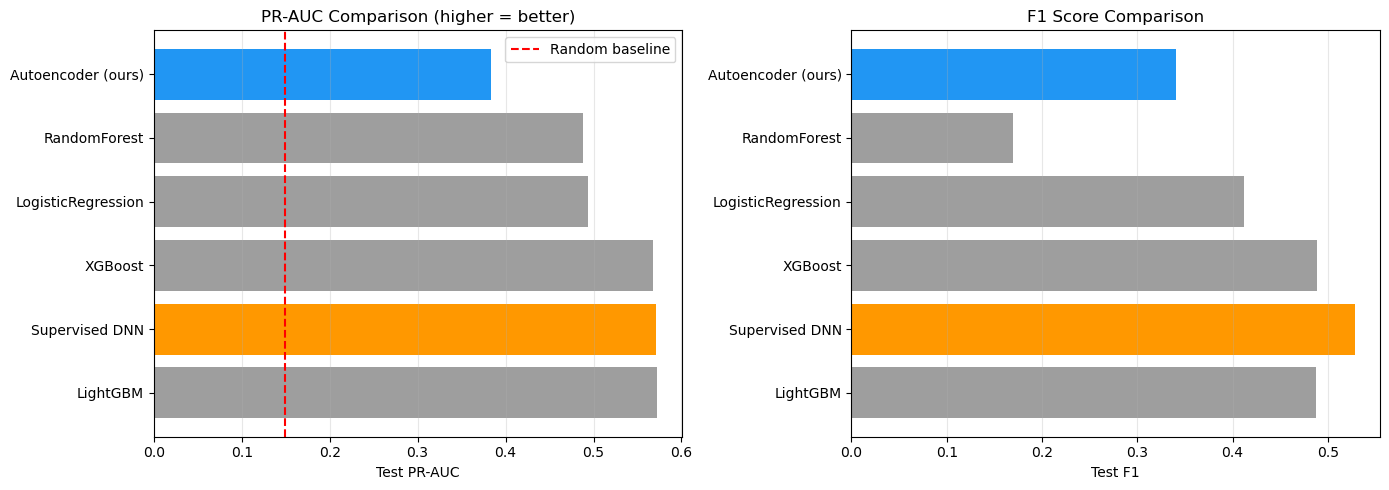

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR-AUC bar chart
models = comparison_df["Model"].tolist()
pr_aucs = comparison_df["PR-AUC"].tolist()
colors = ["#2196F3" if "Autoencoder" in m else "#FF9800" if "DNN" in m else "#9E9E9E" for m in models]
axes[0].barh(models, pr_aucs, color=colors)
axes[0].axvline(x=data["y_test"].mean(), linestyle="--", color="red", label="Random baseline")
axes[0].set_xlabel("Test PR-AUC")
axes[0].set_title("PR-AUC Comparison (higher = better)")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="x")

# F1 bar chart
f1s = comparison_df["F1"].tolist()
axes[1].barh(models, f1s, color=colors)
axes[1].set_xlabel("Test F1")
axes[1].set_title("F1 Score Comparison")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("../figures/fig09_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Save comparison table to CSV for the report
comparison_df.to_csv("../experiments/final_comparison.csv", index=False)
print("Saved to experiments/final_comparison.csv")

Saved to experiments/final_comparison.csv


## 4.7 Discussion

Run the cell below for an auto-generated summary.

In [10]:
# Auto-generated discussion
ae_row = comparison_df[comparison_df["Model"] == "Autoencoder (ours)"].iloc[0]
best_row = comparison_df.iloc[0]
random_bl = data["y_test"].mean()
best_model_name = best_row["Model"]
best_prauc = best_row["PR-AUC"]
ae_prauc = ae_row["PR-AUC"]
ae_f1 = ae_row["F1"]
print("=" * 65)
print("DISCUSSION")
print("=" * 65)
print(f"Best overall model: {best_model_name} (PR-AUC={best_prauc:.4f})")
print(f"Our autoencoder:    PR-AUC={ae_prauc:.4f}  F1={ae_f1:.4f}")
print(f"Random baseline:    PR-AUC={random_bl:.4f}")
print()
print("Key insight:")
print("  Supervised models outperform the autoencoder — this is expected.")
print("  Gradient-boosted trees (XGBoost/LightGBM) are SOTA on tabular data.")
print("  The autoencoder advantage: NO fraud labels needed during training.")
print()
print("Tradeoff:")
print("  Supervised  | Higher performance | Requires labeled fraud data")
print("  Autoencoder | Lower performance  | Works with normal data only")
print("              |                    | Can detect novel/unseen fraud")

DISCUSSION
Best overall model: LightGBM (PR-AUC=0.5725)
Our autoencoder:    PR-AUC=0.3832  F1=0.3410
Random baseline:    PR-AUC=0.1496

Key insight:
  Supervised models outperform the autoencoder — this is expected.
  Gradient-boosted trees (XGBoost/LightGBM) are SOTA on tabular data.
  The autoencoder advantage: NO fraud labels needed during training.

Tradeoff:
  Supervised  | Higher performance | Requires labeled fraud data
  Autoencoder | Lower performance  | Works with normal data only
              |                    | Can detect novel/unseen fraud
